In [55]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# Preprocessing
Firstly we erase the Areas of Interest that aren't related to the main text

In [56]:
df = pd.read_csv('raw/AOIBased.tsv', sep='\t')
to_erase_mochila = ['ColumnaIzquierdaImagenes','MochilaPrincial', 'Pasa', 'el'
            'raton', 'por', 'encima', 'de', 'la', 'imagen', 'para', 'ampliarla', 'Opciones Disponibles', 
            'Color:', 'Negro', 'TiraDeMochilas', 'stock', 'comprar',
            'lista deseos', 'cantidad', 'infoextra', 'cesta', 'ticketregalo']
            
to_erase_patata = ['MenuArriba', 'estrella', 'Titulo', 'MenuApariencia', 'MenuSubtitulo',
            'Contenidos', 'Idiomas', 'TituloImagen', 'Imagen', 'pie de foto', 'taxonomia', 'Reino', 'Plantae']


mask_mochila = ((df['TOI'] == 'MochilaClaro') | (df['TOI'] == 'MochilaOscuro')) & df['AOI'].isin(to_erase_mochila)
df = df.drop(df[mask_mochila].index)

mask_patata = ((df['TOI'] == 'PatataClaro') | (df['TOI'] == 'PatataOscuro')) & df['AOI'].isin(to_erase_patata)
df = df.drop(df[mask_patata].index)


def obtain_basic_data(array):
    mean = np.mean(array)
    
    std = np.std(array)
    max = np.max(array)
    min = np.min(array)
    return mean, std, max, min

Now we separate between the TOI's 

In [57]:
mochila_claro = df[df['TOI'] == 'MochilaClaro']
mochila_oscuro = df[df['TOI'] == 'MochilaOscuro']

patata_claro = df[df['TOI'] == 'PatataClaro']
patata_oscuro = df[df['TOI'] == 'PatataOscuro']


We now need to calculate the total fixations per participant in that main text which is done in the following cell.

In [58]:
# Recording es el participane
sum_mochila_claro = mochila_claro.groupby('Recording')['Number_of_fixations'].sum()
sum_mochila_oscuro = mochila_oscuro.groupby('Recording')['Number_of_fixations'].sum()
sum_patata_claro = patata_claro.groupby('Recording')['Number_of_fixations'].sum()
sum_patata_oscuro = patata_oscuro.groupby('Recording')['Number_of_fixations'].sum()


We will obtain the basic data:

In [59]:
basic_data = {
    'PatataClaro': obtain_basic_data(sum_patata_claro),
    'PatataOscuro': obtain_basic_data(sum_patata_oscuro),
    'MochilaClaro': obtain_basic_data(sum_mochila_claro),
    'MochilaOscuro': obtain_basic_data(sum_mochila_oscuro)
}

    
for key in basic_data:
    print(f"Results for {key}:")
    print("[Mean: {:.2f}] [Std: {:.2f}] [Max: {:.2f}] [Min: {:.2f}]".format(*basic_data[key]))
    print()

Results for PatataClaro:
[Mean: 109.18] [Std: 43.73] [Max: 219.00] [Min: 35.00]

Results for PatataOscuro:
[Mean: 105.65] [Std: 41.38] [Max: 182.00] [Min: 7.00]

Results for MochilaClaro:
[Mean: 331.24] [Std: 167.07] [Max: 573.00] [Min: 21.00]

Results for MochilaOscuro:
[Mean: 361.59] [Std: 130.93] [Max: 592.00] [Min: 103.00]



# Processing
Firstly we check the normality of the data

In [60]:

w_stat, p_value = stats.shapiro(sum_mochila_claro)
print(f"Mochila Claro: Shapiro-Wilk W={w_stat:.4f}, p-value={p_value:.4f}, Normal: {p_value > 0.05}")

w_stat,p_value = stats.shapiro(sum_mochila_oscuro)
print(f"Mochila Oscuro: Shapiro-Wilk W={w_stat:.4f}, p-value={p_value:.4f}, Normal: {p_value > 0.05}")

w_stat, p_value = stats.shapiro(sum_patata_claro)
print(f"Patata Claro: Shapiro-Wilk W={w_stat:.4f}, p-value={p_value:.4f}, Normal: {p_value > 0.05}")

w_stat, p_value = stats.shapiro(sum_patata_oscuro)
print(f"Patata Oscuro: Shapiro-Wilk W={w_stat:.4f}, p-value={p_value:.4f}, Normal: {p_value > 0.05}")

Mochila Claro: Shapiro-Wilk W=0.9188, p-value=0.1412, Normal: True
Mochila Oscuro: Shapiro-Wilk W=0.9724, p-value=0.8597, Normal: True
Patata Claro: Shapiro-Wilk W=0.9308, p-value=0.2248, Normal: True
Patata Oscuro: Shapiro-Wilk W=0.9778, p-value=0.9346, Normal: True


Given the fact that all of the values follow normality the T-Student and Mann-Whitney U Tests are done

In [61]:
mann_mochila = stats.mannwhitneyu(sum_mochila_claro, sum_mochila_oscuro, alternative='two-sided')
mann_patata = stats.mannwhitneyu(sum_patata_claro, sum_patata_oscuro, alternative='two-sided')
print(f"Mann-Whitney U test for Mochila: P-value = {mann_mochila.pvalue:.4f} Statistic = {mann_mochila.statistic:.4f}")
print(f"Mann-Whitney U test for Patata: P-value = {mann_patata.pvalue:.4f} Statistic = {mann_patata.statistic:.4f}")

t_mochila = stats.ttest_ind(sum_mochila_claro, sum_mochila_oscuro, equal_var=False)
t_patata = stats.ttest_ind(sum_patata_claro, sum_patata_oscuro, equal_var=False)
print(f"T-test for Mochila: P-value = {t_mochila.pvalue:.4f} Statistic = {t_mochila.statistic:.4f}")
print(f"T-test for Patata: P-value = {t_patata.pvalue:.4f} Statistic = {t_patata.statistic:.4f}")

Mann-Whitney U test for Mochila: P-value = 0.8633 Statistic = 139.0000
Mann-Whitney U test for Patata: P-value = 0.8496 Statistic = 138.5000
T-test for Mochila: P-value = 0.5715 Statistic = -0.5720
T-test for Patata: P-value = 0.8161 Statistic = 0.2345


# Results
The following plot shows the results of the Mann-Whitney along with the number of fixations per recording

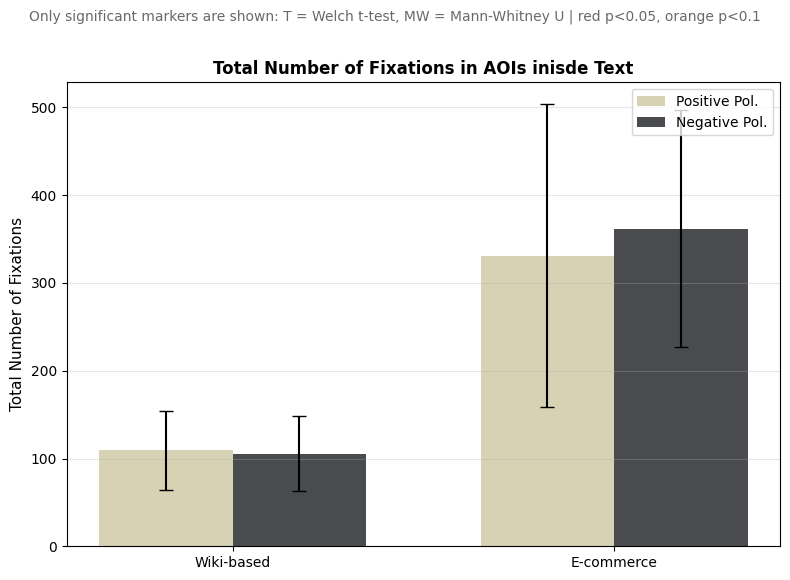

In [62]:
# Calculate means and standard deviations of the total fixations per recording
claro_means = [
    sum_patata_claro.mean(),
    sum_mochila_claro.mean()
]
claro_stds = [
    sum_patata_claro.std(),
    sum_mochila_claro.std()
]

oscuro_means = [
    sum_patata_oscuro.mean(),
    sum_mochila_oscuro.mean()
]
oscuro_stds = [
    sum_patata_oscuro.std(),
    sum_mochila_oscuro.std()
]

# Configure plot variables
toi_labels = ['Wiki-based', 'E-commerce']
x = np.arange(len(toi_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    x - width / 2,
    claro_means,
    width,
    yerr=claro_stds,
    label='Positive Pol.',
    color='#CEC7A2',
    alpha=0.8,
    capsize=5,
)
ax.bar(
    x + width / 2,
    oscuro_means,
    width,
    yerr=oscuro_stds,
    label='Negative Pol.',
    color='#1D1E22',
    alpha=0.8,
    capsize=5,
)

# Add statistical significance markers
pvalues = [mann_patata.pvalue, mann_mochila.pvalue]

for j, scenario in enumerate(toi_labels):
    y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])
    pvalue = pvalues[j]
    
    if pvalue >= 0.1:
        continue

    color = 'red' if pvalue < 0.05 else 'orange'

    ax.text(
        x[j],
        y_pos * 1.06,
        'MW',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=color,
    )

ax.set_ylabel('Total Number of Fixations', fontsize=11)
ax.set_title('Total Number of Fixations in AOIs inisde Text', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(toi_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

fig.text(
    0.5,
    0.94,
    'Only significant markers are shown: T = Welch t-test, MW = Mann-Whitney U | red p<0.05, orange p<0.1',
    ha='center',
    fontsize=10,
    color='dimgray',
)
plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig(f'output/figures/regressions.png', dpi=300, bbox_inches='tight')
plt.show()